# 06. 시계열 딥러닝 (LSTM / GRU)

04~05에서는 각 분기를 **독립적인 표(tabular) 샘플**로 보고 lag 피처로 과거 정보를 넣었습니다.
이 노트북에서는 한 걸음 더 나아가, 각 (자치구 × 업종)의 분기 흐름을 **시퀀스 그대로** 입력하는
순환신경망(LSTM / GRU)을 적용해 봅니다.

## 접근
- 각 (자치구 × 업종) 그룹을 하나의 시계열로 취급
- 과거 **5개 분기** `[t-5 … t-1]`의 피처 시퀀스 → 다음 분기 `t`의 폐업 위험(0/1) 예측
- 타깃이 **미래 분기**이므로 데이터 누수 없음
- 타겟 기준·분할 방식은 04·05와 동일 (폐업률 중앙값 이진화, 시계열 순서 분할)

## 목적
성능 경쟁이 아니라, **시계열을 시퀀스로 직접 모델링했을 때** tabular 부스팅(CatBoost) 대비
어떤 결과가 나오는지 확인하고 그 이유를 해석하는 데 있습니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
WINDOW = 5  # 과거 5분기로 다음 분기 예측
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cpu


## 1. 데이터 로드 및 인코딩

`00_data_merge`의 통합 데이터(137컬럼)에서 시작합니다. 범주형은 정수 인코딩하고,
타겟은 04·05와 동일하게 폐업률 중앙값 기준으로 이진화합니다.

In [2]:
df = pd.read_csv('../data/processed/merged_data.csv', encoding='utf-8-sig')
df['yq'] = (df['기준_년분기_코드'].astype(str).str[:4].astype(int) * 10
            + df['기준_년분기_코드'].astype(str).str[4:].astype(int))

for col, name in [('자치구_코드_명', 'gu'), ('서비스_업종_코드_명', 'up'), ('상권_변화_지표', 'sg')]:
    df[name] = LabelEncoder().fit_transform(df[col])

threshold = df['폐업_률'].quantile(0.5)
df['y'] = (df['폐업_률'] >= threshold).astype(int)
print(f'타겟 임계값(중앙값): {threshold:.2f}%')

# 입력 피처: 폐업 관련(누수) 컬럼 제외
exclude = ['기준_년분기_코드', '자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표',
           '폐업_률', '폐업_점포_수', '운영_영업_개월_평균', '서울시_운영_영업_개월_평균', 'yq', 'y']
cat_feats = ['gu', 'up', 'sg']
num_feats = [c for c in df.columns if c not in exclude and c not in cat_feats]
feat_cols = cat_feats + num_feats
n_cat = len(cat_feats)
print(f'입력 피처: {len(feat_cols)}개 (범주형 {n_cat} + 수치형 {len(num_feats)})')

타겟 임계값(중앙값): 2.30%
입력 피처: 132개 (범주형 3 + 수치형 129)


## 2. 시퀀스 데이터 구성

각 (자치구 × 업종) 그룹을 분기 순으로 정렬한 뒤, 슬라이딩 윈도우로
`(과거 5분기 피처) → (다음 분기 위험)` 쌍을 만듭니다.

In [3]:
df = df.sort_values(['gu', 'up', 'yq']).reset_index(drop=True)

X_seq, y_seq, meta = [], [], []
for (gu, up), g in df.groupby(['gu', 'up']):
    g = g.sort_values('yq')
    v = g[feat_cols].values.astype(np.float32)
    t = g['y'].values
    q = g['yq'].values
    for i in range(WINDOW, len(g)):
        X_seq.append(v[i-WINDOW:i])   # 과거 5분기
        y_seq.append(t[i])            # 다음 분기 타깃
        meta.append(q[i])             # 예측 대상 분기

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)
meta = np.array(meta)

print(f'시퀀스 텐서: {X_seq.shape}  (샘플, 타임스텝, 피처)')
print(f'양성 비율: {y_seq.mean():.3f}')
print(f'예측 대상 분기: {meta.min()} ~ {meta.max()}')

시퀀스 텐서: (32220, 5, 132)  (샘플, 타임스텝, 피처)
양성 비율: 0.499
예측 대상 분기: 20202 ~ 20252


## 3. 시계열 순서 분할 및 스케일링

예측 대상 분기 기준으로 정렬한 뒤 시간 순서대로 Train 70% / Val 10% / Test 20% 분할합니다.
연속형 피처는 **train에서만** `StandardScaler`를 fit 합니다.

In [4]:
order = np.argsort(meta, kind='stable')
X_seq, y_seq = X_seq[order], y_seq[order]

n = len(X_seq)
ntr, nval = int(n * 0.7), int(n * 0.1)
X_train, X_val, X_test = X_seq[:ntr], X_seq[ntr:ntr+nval], X_seq[ntr+nval:]
y_train, y_val, y_test = y_seq[:ntr], y_seq[ntr:ntr+nval], y_seq[ntr+nval:]

# 스케일링 (train 수치형만 fit)
scaler = StandardScaler().fit(X_train[:, :, n_cat:].reshape(-1, len(num_feats)))
def scale(X):
    X = X.copy()
    flat = X[:, :, n_cat:].reshape(-1, len(num_feats))
    X[:, :, n_cat:] = scaler.transform(flat).reshape(X.shape[0], WINDOW, len(num_feats))
    return X
X_train, X_val, X_test = scale(X_train), scale(X_val), scale(X_test)

print(f'Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}')
print(f'양성비율 → train {y_train.mean():.3f}, val {y_val.mean():.3f}, test {y_test.mean():.3f}')

def make_loader(X, y, bs, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_dl = make_loader(X_train, y_train, 256, True)
val_dl = make_loader(X_val, y_val, 512, False)
test_dl = make_loader(X_test, y_test, 512, False)

Train (22554, 5, 132), Val (3222, 5, 132), Test (6444, 5, 132)
양성비율 → train 0.486, val 0.565, test 0.514


## 4. 모델 정의 (LSTM / GRU 공용)

순환층으로 시퀀스를 인코딩하고, 마지막 타임스텝의 은닉 상태를 분류기에 통과시킵니다.

In [5]:
class RNNClassifier(nn.Module):
    def __init__(self, kind, n_feat, hidden=64, layers=2, drop=0.3):
        super().__init__()
        rnn = nn.LSTM if kind == 'lstm' else nn.GRU
        self.rnn = rnn(n_feat, hidden, layers, batch_first=True,
                       dropout=drop if layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(drop), nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :]).squeeze(-1)  # 마지막 타임스텝


def train_and_eval(kind, epochs=40, patience=8):
    torch.manual_seed(SEED)
    model = RNNClassifier(kind, X_train.shape[2]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    lossf = nn.BCEWithLogitsLoss()

    best_auc, best_state, wait, history = 0.0, None, 0, []
    for ep in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward()
            opt.step()
        # validation
        model.eval(); ps, ts = [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                ps.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
                ts.append(yb.numpy())
        auc = roc_auc_score(np.concatenate(ts), np.concatenate(ps))
        history.append(auc)
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval(); ps, ts = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            ps.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
            ts.append(yb.numpy())
    proba, true = np.concatenate(ps), np.concatenate(ts)
    pred = (proba >= 0.5).astype(int)
    metrics = {
        'Accuracy': accuracy_score(true, pred),
        'F1-Score': f1_score(true, pred),
        'ROC-AUC': roc_auc_score(true, proba),
        'best_val_auc': best_auc,
        'epochs': len(history),
    }
    return metrics, proba, true

## 5. 학습 및 평가

In [6]:
results = {}
probas = {}
for kind in ['lstm', 'gru']:
    m, proba, true = train_and_eval(kind)
    results[kind.upper()] = m
    probas[kind.upper()] = (proba, true)
    print(f"[{kind.upper()}] Acc={m['Accuracy']:.4f}  F1={m['F1-Score']:.4f}  "
          f"AUC={m['ROC-AUC']:.4f}  (best val AUC={m['best_val_auc']:.4f}, {m['epochs']} epochs)")

[LSTM] Acc=0.7061  F1=0.6832  AUC=0.7750  (best val AUC=0.8051, 22 epochs)


[GRU] Acc=0.6997  F1=0.6865  AUC=0.7787  (best val AUC=0.8028, 24 epochs)


## 6. CatBoost(04)와 비교

04에서 최고였던 CatBoost 성능을 기준선으로 함께 표시합니다.

In [7]:
compare = pd.DataFrame({
    'CatBoost (04)': {'Accuracy': 0.7127, 'F1-Score': 0.6944, 'ROC-AUC': 0.7955},
    'LSTM': {k: results['LSTM'][k] for k in ['Accuracy', 'F1-Score', 'ROC-AUC']},
    'GRU': {k: results['GRU'][k] for k in ['Accuracy', 'F1-Score', 'ROC-AUC']},
}).T
compare.round(4)

,Accuracy,F1-Score,ROC-AUC
CatBoost (04),0.7127,0.6944,0.7955
LSTM,0.7061,0.6832,0.7750
GRU,0.6997,0.6865,0.7787


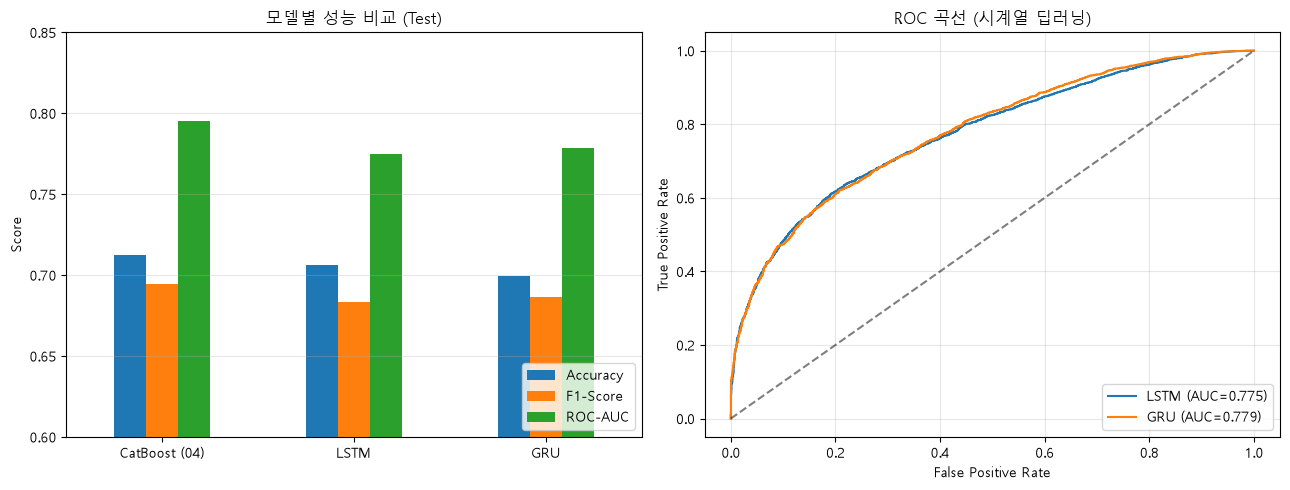

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

compare.plot(kind='bar', ax=axes[0], rot=0, ylim=(0.6, 0.85))
axes[0].set_title('모델별 성능 비교 (Test)')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

for name in ['LSTM', 'GRU']:
    proba, true = probas[name]
    fpr, tpr, _ = roc_curve(true, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선 (시계열 딥러닝)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 결과 해석

### 관찰
- LSTM/GRU 모두 정상적으로 학습되며, 검증 AUC는 0.80 부근까지 도달
- **테스트 성능은 CatBoost(AUC 0.796)보다 근소하게 낮음** (LSTM/GRU AUC ≈ 0.775~0.779)
- 짧은 시퀀스에서는 GRU가 LSTM보다 약간 우세

### 왜 시계열 딥러닝이 부스팅을 넘지 못했나
1. **시퀀스가 짧고 데이터가 작다** — 전체 26분기, 윈도우 5분기. RNN이 강점을 보이는 긴 시퀀스/대규모 데이터와 거리가 있음
2. **이질적·범주형 피처** — 자치구/업종 등 범주형과 스케일이 제각각인 수치형이 섞여 있어, 이런 tabular 구조에서는 gradient boosting이 구조적으로 유리
3. **약한 시간 의존성** — 폐업률의 분기 간 자기상관이 강하지 않아, 시퀀스 모델이 얻는 추가 정보가 제한적

### 결론
> 시계열을 시퀀스로 직접 모델링한 시도 자체는 의미가 있었으나,
> **이 데이터 규모·구조에서는 CatBoost가 여전히 최적**이라는 점을 실측으로 확인했다.
> 최신 기법을 무조건 적용하기보다, 데이터 특성에 맞는 모델을 선택하는 것이 중요하다.

→ 최종 서비스 모델은 05의 CatBoost를 유지